# Softmax Regression
In machine learning, softmax regression is used to define a **multi-class classifier** for **supervised learning**. It is also used to define neural networks.

Mathematically, softmax regression represents a generalization of logistic regression. For this reason, it is also known as **multinomial logistic regression**.

<div class="alert alert-block alert-warning">
    This notes assume that the reader has already read the ones about logistic regression. Thus, they won't go as in depth about some foundational concepts.
</div>

# Mathematical Overview
Softmax regression is based on the **softmax function**:
$$
\mathrm{softmax}(W, X)_i = \frac{e^{X \boldsymbol w_i}}{\sum_{i=1}^{\mathrm{num\_classes}} e^{X\boldsymbol w_j}}
$$
where the computed value with subscript $i$ is referred to the probability associated with the $i$-th class.

# Example
Let's see a simple example using the **UCI ML hand-written digits dataset**, which has the following properties:
<table style="margin-left: auto; margin-right: auto;">
    <tr>
        <th>Classes</th>
        <td>10</td>
    </tr>
    <tr>
      <th>Samples per class</th>
      <td>&#126;180</td>
    </tr>
    <tr>
      <th>Samples total</th>
      <td>1797</td>
    </tr>
    <tr>
      <th>Dimensionality</th>
      <td>64</td>
    </tr>
    <tr>
      <th>Features</th>
      <td>integers 0-16</td>
    </tr>
</table>

In [1]:
%matplotlib inline
from sklearn.datasets import load_digits # For the dataset
from sklearn.model_selection import train_test_split # For splitting the entire dataset in learning and testing subsets
from sklearn.metrics import confusion_matrix, classification_report # For classification evaluation
from sklearn.preprocessing import StandardScaler # For data standardization
from mlpack.logistic_regression import SoftmaxRegression # SoftmaxRegression class
import matplotlib.pyplot as plt # For plotting the loss function

# Load dataset
X, y = load_digits(return_X_y = True)

sc = StandardScaler()
X = sc.fit_transform(X=X, y=y)

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.3,   # Set proportion of the dataset to include in the testing subset 
    random_state = 42  # Set seed of random generator in order to ensure reproducibility of the results
)

# Instantiate SoftmaxRegression object
clf = SoftmaxRegression(
    bias = 0,
    learning_rate = 0.3,
    patience = 1000,
    tolerance = 1e-3,
    regularization = 1e-2
)

# Apply learning algorithm to the training subset
#NOTE: it may take some time (depending on set patience) since the underlying training algorithm is not very 
#      efficient right now
clf.fit(X_train, y_train)

# Classify the testing subset
pred = clf.predict(X_test)

# Print sklearn's classification report and the confusion matrix in order to evaluate the learning results
print("==== Classification report ====")
print(classification_report(y_test, pred))

print("==== Confusion matrix ====")
print(confusion_matrix(y_test, pred))

==== Classification report ====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.92      0.94        50
           2       0.94      1.00      0.97        47
           3       1.00      0.94      0.97        54
           4       1.00      0.98      0.99        60
           5       0.93      0.94      0.93        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.91      0.98      0.94        43
           9       0.97      0.97      0.97        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540

==== Confusion matrix ====
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 46  2  0  0  1  0  0  1  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 51  0  1  0  0  1  0]
 [ 0  1  0  0 59  0  0  0  0  0]
 [ 0  1  0  0  0 

# Loss Function
The package implements the **cross-entropy loss function** for softmax regression:
$$
l(\boldsymbol Y, \boldsymbol Y') = -\sum_i^{\mathrm{num\_classes}}\sum_j^{\mathrm{num\_samples}}[Y_{ij}\log{Y'_{ij}}]
$$

As usual, the library allows to see the loss function evolution over training epochs of a classifier using the `plot_loss_curve()` method.

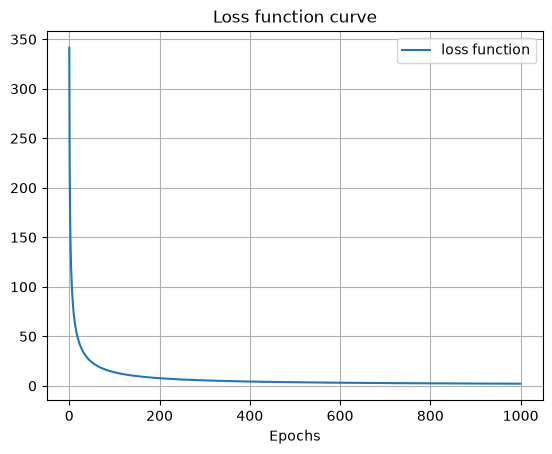

In [3]:
# Visualize loss function
clf.plot_loss_curve(label="loss function")

plt.show()

# Resources
- Wikipedia page on the [softmax function](https://en.wikipedia.org/wiki/Softmax_function).
- "Dive into Deep Learning" page on [softmax regression](https://d2l.ai/chapter_linear-classification/softmax-regression.html).